<a href="https://colab.research.google.com/github/samueleborgognoni/kmeans_nn_ILF_london_smart_meters/blob/main/4_2_Load_Forecasting_with_lags_WITHOUT_MEAN_CLUSTER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAOD FORECASTING with KMEANS-NN methodology

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [ ]:
from google.colab import drive
drive.mount('/content/drive') # <- activate to use Google Colab

drive_folder_path = '/content/drive/MyDrive/-Career📚/_UNIVERSITY/__Macchine_ed_azionamenti_elettrici/_Progetto_MAE/mae_proj/'

Mounted at /content/drive


In [ ]:
# Import normalized dataset with extracted features for each household + cluster_id
# 750 households | 21features

df_ID = pd.read_csv(drive_folder_path + 'data/df_extracted_norm_clusters.csv')
print(df_ID.shape)

# Display the header of df
df_ID.head(5)


(750, 21)


,LCLid,TKWh,Avg_hourly,Avg_daily,Avg_weekly,Avg_monthly,Avg_Mon,Avg_Tue,Avg_Wed,Avg_Thu,...,Avg_Sat,Avg_Sun,Avg_weekend,Avg_workday,Avg_EAN,Avg_EM,Avg_LAN,Avg_M,Avg_N,cluster
0,MAC000002,0.092808,0.119064,0.119091,0.092730,0.092748,0.106704,0.115783,0.116458,0.110815,...,0.129685,0.136349,0.133041,0.113841,0.101038,0.058083,0.139120,0.134053,0.108316,0
1,MAC000005,0.044275,0.044815,0.044814,0.044193,0.044212,0.047150,0.043271,0.043760,0.040864,...,0.046777,0.048089,0.047438,0.043839,0.056807,0.033419,0.053597,0.043171,0.027675,12
2,MAC000017,0.079150,0.062699,0.062711,0.079071,0.079089,0.058711,0.054760,0.066287,0.060508,...,0.065469,0.070808,0.068158,0.060662,0.069390,0.041732,0.067978,0.070293,0.046751,4
3,MAC000026,0.154388,0.122669,0.122716,0.154316,0.154332,0.145715,0.139435,0.146693,0.133019,...,0.084117,0.096136,0.090169,0.134817,0.101975,0.118212,0.098477,0.165218,0.100686,2
4,MAC000030,0.141243,0.112202,0.112246,0.141169,0.141186,0.110712,0.084389,0.094108,0.096926,...,0.135740,0.176306,0.156168,0.095785,0.144518,0.077225,0.124258,0.126159,0.069790,5


In [ ]:
def get_df_hourly(df:pd.DataFrame):
  '''Create a new pd.DataFrame with the energy measurementents
  resampled every hour'''
  # Convert timestamps from str to datetime
  df['tstp'] = pd.to_datetime(df['tstp'])
  # Resample the df
  df_hourly = (
      df
      .set_index('tstp')
      .groupby('LCLid')
      .resample('1h')['energy(kWh/hh)']
      .sum()
      .reset_index()
  )
  return df_hourly.rename(columns={'energy(kWh/hh)': 'energy(kWh)'})

# Import the time series dataset and resample it into hourly
df_time = get_df_hourly(pd.read_csv(drive_folder_path + 'data/df_cleaned.csv'))

df_time

,LCLid,tstp,energy(kWh)
0,MAC000002,2012-10-12 00:00:00,0.073000
1,MAC000002,2012-10-12 01:00:00,0.146000
2,MAC000002,2012-10-12 02:00:00,0.146000
3,MAC000002,2012-10-12 03:00:00,0.146000
4,MAC000002,2012-10-12 04:00:00,0.146000
...,...,...,...
11224948,MAC005565,2012-12-19 08:00:00,0.000000
11224949,MAC005565,2012-12-19 09:00:00,0.000000
11224950,MAC005565,2012-12-19 10:00:00,0.000000
11224951,MAC005565,2012-12-19 11:00:00,0.000000


### Prepare the time dataframe for the cluster load forecasting

In [ ]:
# Assign its cluster ID to each meter
df_time_clusterID = df_time.merge(df_ID[['LCLid', 'cluster']], on='LCLid', how='left')

# Display 10 rand samples to check the cluster ID
l = np.random.randint(0, len(df_time_clusterID), 10).tolist()
df_time_clusterID.iloc[l]


,LCLid,tstp,energy(kWh),cluster
2509071,MAC001584,2012-12-21 06:00:00,0.105,12
9903436,MAC005273,2012-12-12 17:00:00,0.212,9
4007891,MAC002497,2013-07-13 14:00:00,0.641,0
6858372,MAC003656,2012-12-10 09:00:00,1.306,5
10828097,MAC005399,2013-08-26 08:00:00,0.159,2
9057960,MAC004924,2013-01-26 12:00:00,0.863,4
6753414,MAC003584,2013-11-02 12:00:00,0.129,12
586373,MAC000304,2012-09-04 02:00:00,0.526,5
189813,MAC000079,2013-12-20 09:00:00,0.295,6
6597363,MAC003499,2012-10-10 13:00:00,0.053,9


In [ ]:
# Group hourly samples based on the cluster ID + calc the mean
df_time_mean_cluster = (
    df_time_clusterID
    .groupby(['cluster', 'tstp'])['energy(kWh)']
    .mean()
    .reset_index()
)
# df_time_mean_cluster.to_csv(drive_folder_path + 'data/df_time_mean_cluster.csv') <-- uncomment to save .csv
df_time_mean_cluster

,cluster,tstp,energy(kWh)
0,0,2011-11-28 12:00:00,0.214000
1,0,2011-11-28 13:00:00,0.183000
2,0,2011-11-28 14:00:00,0.295000
3,0,2011-11-28 15:00:00,0.194000
4,0,2011-11-28 16:00:00,0.326000
...,...,...,...
245643,12,2014-02-27 20:00:00,0.411215
245644,12,2014-02-27 21:00:00,0.401348
245645,12,2014-02-27 22:00:00,0.355813
245646,12,2014-02-27 23:00:00,0.263167


### Analyse autocorrelation

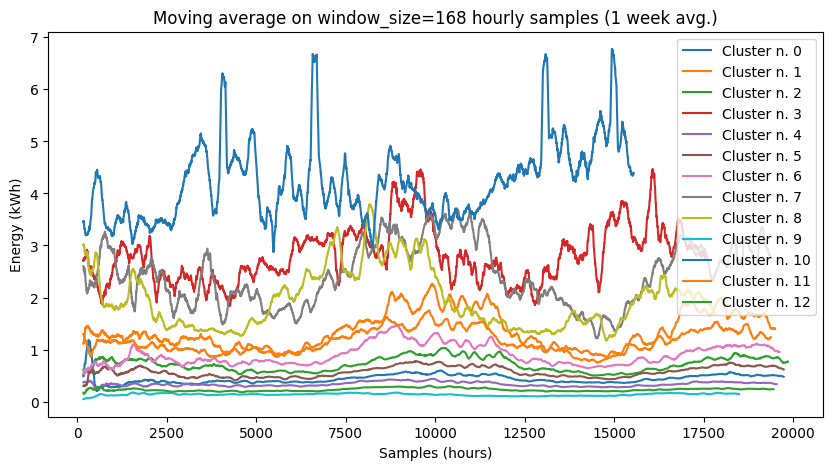

In [ ]:
# PLOT THE MOVING AVERAGE FOR EACH CLUSTER TO SHOW THE NON-STATIONARITY

window_size = 24*7 # hrs in 1 week

plt.figure(figsize=(10,5))

for _cluster_id in range(max(df_time_mean_cluster['cluster']) + 1):
  # _cluster_id = 1
  __df = df_time_mean_cluster[df_time_mean_cluster['cluster'] == _cluster_id]

  # Rolling mean e rolling std
  rolling_mean = __df['energy(kWh)'].rolling(window=window_size).mean()
  plt.plot(range(0,len(__df)),rolling_mean, label=f'Cluster n. {_cluster_id}')

plt.title(f'Moving average on window_size={window_size} hourly samples (1 week avg.)')
plt.ylabel('Energy (kWh)')
plt.xlabel('Samples (hours)')
plt.legend()
plt.show()

[1.         0.81295702 0.78643699 0.77108582 0.7558412  0.74783616
 0.75231535 0.7638341  0.7365033 ]


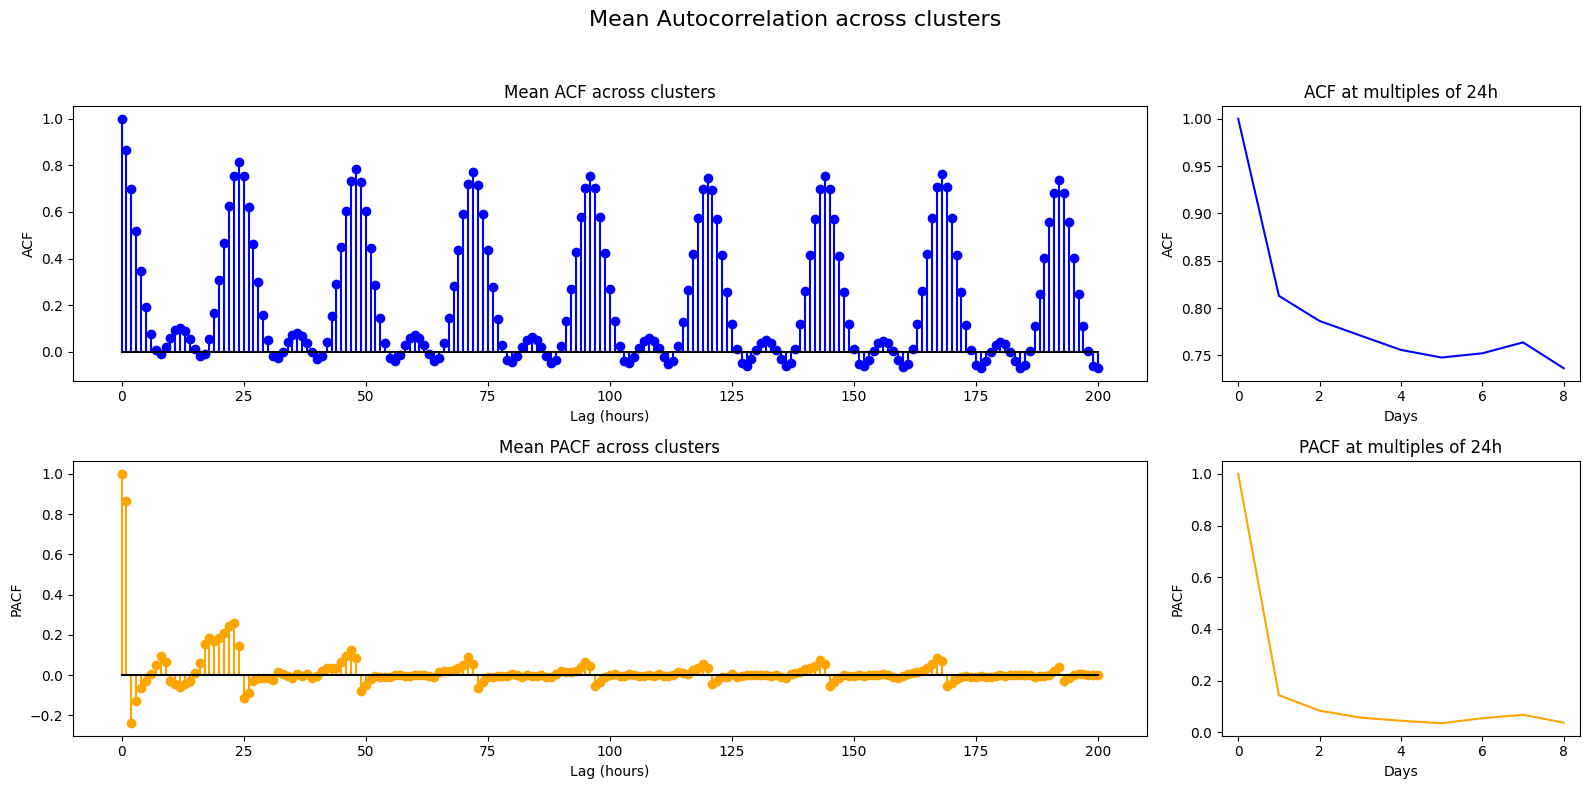

In [ ]:
# ANALYSE THE AUTOCORRELATION TO IDENTIFY SEASONALITY

from statsmodels.graphics.tsaplots import acf, pacf, plot_acf, plot_pacf
from matplotlib.gridspec import GridSpec

n_lags = 200

cluster_ids = sorted(df_time_mean_cluster['cluster'].unique())
n_clusters = len(cluster_ids)

acf_arr = np.zeros((n_clusters, n_lags + 1))
pacf_arr = np.zeros((n_clusters, n_lags + 1))

for idx, cluster_id in enumerate(cluster_ids):

    _df = df_time_mean_cluster[df_time_mean_cluster['cluster'] == cluster_id]

    acf_arr[idx, :] = acf(_df['energy(kWh)'], nlags=n_lags)
    pacf_arr[idx, :] = pacf(_df['energy(kWh)'], nlags=n_lags)

# Mean acf/pacf between clusters for each lag
acf_mean = np.mean(acf_arr, axis=0)
pacf_mean = np.mean(pacf_arr, axis=0)

# Analyse the daily max autocorrelation
__idx = range(0, n_lags+1, 24)
_p_acf = acf_mean[__idx]
_p_pacf = pacf_mean[__idx]
print(_p_acf)



# PLOTS
_lags = np.arange(len(acf_mean))
fig = plt.figure(figsize=(16, 8))

# Make left col wider than right one in the subplot (3:1)
gs = GridSpec(2, 2, figure=fig, width_ratios=[3,1])

# ACF mean
ax0 = fig.add_subplot(gs[0,0])
ax0.stem(_lags, acf_mean, linefmt='b-', markerfmt='bo', basefmt='k-')
ax0.set_title('Mean ACF across clusters')
ax0.set_xlabel('Lag (hours)')
ax0.set_ylabel('ACF')

# PACF mean
ax1 = fig.add_subplot(gs[1,0])
ax1.stem(_lags, pacf_mean, linefmt='orange', markerfmt='o', basefmt='k-')
ax1.set_title('Mean PACF across clusters')
ax1.set_xlabel('Lag (hours)')
ax1.set_ylabel('PACF')

# Daily max ACF
ax2 = fig.add_subplot(gs[0,1])
ax2.plot(_p_acf, color='b')
ax2.set_title('ACF at multiples of 24h')
ax2.set_xlabel('Days')
ax2.set_ylabel('ACF')

# Daily max PACF
ax3 = fig.add_subplot(gs[1,1])
ax3.plot(_p_pacf, color='orange')
ax3.set_title('PACF at multiples of 24h')
ax3.set_xlabel('Days')
ax3.set_ylabel('PACF')

plt.suptitle('Mean Autocorrelation across clusters', fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


### Feature engineering and LAGS + Train/Test split (function)

Create new features for hour, day of the week, month. Then turn them into sin() values to express the seasonality over the day, the week and the month, so that samples near the same time have similar values.

Let's define the following time angles for the sin() functions:

$\theta_{hour}=2\pi\,\frac{hour\,of\,day}{24}$

$\theta_{day}=2\pi\,\frac{day\,of\,week}{7}$

$\theta_{month}=2\pi\,\frac{month\,of\,year}{12}$

In [ ]:
def feature_eng(df: pd.DataFrame, lag_168=True, sin_val=True, col_name='cluster'):
  '''Create a new dataframe with time features.
  col_name -> name of the col to group the df with (to create lags)'''

  X_tot = df.copy()
  # Create new features for hour, dayofweek, month
  X_tot['hour'] = X_tot['tstp'].dt.hour
  X_tot['dayofweek'] = X_tot['tstp'].dt.dayofweek
  X_tot['month'] = X_tot['tstp'].dt.month
  X_tot.drop(columns='tstp')

  if sin_val:
    # Turn the features into sin() and cos() values -> [also, in this way the values are normalized in (-1,+1)]
    X_tot['hour_sin'] = np.sin(2 * np.pi * X_tot['hour'] / 24)
    X_tot['hour_cos'] = np.cos(2 * np.pi * X_tot['hour'] / 24)
    X_tot['day_sin'] = np.sin(2 * np.pi * X_tot['dayofweek'] / 7)
    X_tot['day_cos'] = np.cos(2 * np.pi * X_tot['dayofweek'] / 7)
    X_tot['month_sin'] = np.sin(2 * np.pi * X_tot['month'] / 12)
    X_tot['month_cos'] = np.cos(2 * np.pi * X_tot['month'] / 12)


  # Create lags to make methods like MLP have a memory and learn auto-correlation
  X_tot['lag_1'] = (
    X_tot
    .groupby(col_name)['energy(kWh)']
    .shift(1)
    )
  X_tot['lag_24'] = (
    X_tot
    .groupby(col_name)['energy(kWh)']
    .shift(24)
    )
  if lag_168:
    X_tot['lag_168'] = (
      X_tot
      .groupby(col_name)['energy(kWh)']
      .shift(168)
      )

  if sin_val:
    # Remove unuseful/redundant features
    X_tot = X_tot.drop(columns=['hour', 'dayofweek', 'month'])

  # Convert 'tstp' to datetime
  X_tot['tstp'] = pd.to_datetime(X_tot['tstp'])

  # Set 'tstp' as index column
  X_tot = X_tot.set_index('tstp')

  # Remove NaN samples (first 168 rows), that have been created by the shifting
  return X_tot.dropna()



def train_test_split(X_tot: pd.DataFrame,
                     cluster_id, filter_cluster=True, train_ratio=0.7):
  '''Splits the time series into train and test sets'''

  if filter_cluster:
    # Filter the df taking only the samples with same cluster_id
    X_tot = X_tot[X_tot['cluster'] == cluster_id].copy()

  # Calc split indexes
  split_idx = int(len(X_tot) * train_ratio)

  # Train/Test dataset split
  X_tot_train = X_tot.iloc[:split_idx].astype(float)
  X_tot_test  = X_tot.iloc[split_idx:].astype(float)


  # Energy load time series
  y_train = X_tot_train['energy(kWh)']
  y_test = X_tot_test['energy(kWh)']

  # Features time series
  X_train = X_tot_train.drop(columns='energy(kWh)')
  X_test = X_tot_test.drop(columns='energy(kWh)')

  return y_train, y_test, X_train, X_test


In [ ]:
# Check the total dataset after feature engineering
_d = feature_eng(df_time_mean_cluster, lag_168=True, sin_val=True)
_d

,cluster,energy(kWh),hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,lag_1,lag_24,lag_168
tstp,,,,,,,,,,,
2011-12-05 12:00:00,0,0.206000,1.224647e-16,-1.000000,0.000000,1.000000,-2.449294e-16,1.0,0.605000,0.142000,0.214000
2011-12-05 13:00:00,0,0.157000,-2.588190e-01,-0.965926,0.000000,1.000000,-2.449294e-16,1.0,0.206000,1.136000,0.183000
2011-12-05 14:00:00,0,0.226000,-5.000000e-01,-0.866025,0.000000,1.000000,-2.449294e-16,1.0,0.157000,1.797000,0.295000
2011-12-05 15:00:00,0,0.182000,-7.071068e-01,-0.707107,0.000000,1.000000,-2.449294e-16,1.0,0.226000,1.157000,0.194000
2011-12-05 16:00:00,0,0.282000,-8.660254e-01,-0.500000,0.000000,1.000000,-2.449294e-16,1.0,0.182000,1.969000,0.326000
...,...,...,...,...,...,...,...,...,...,...,...
2014-02-27 20:00:00,12,0.411215,-8.660254e-01,0.500000,0.433884,-0.900969,8.660254e-01,0.5,0.397441,0.358761,0.370673
2014-02-27 21:00:00,12,0.401348,-7.071068e-01,0.707107,0.433884,-0.900969,8.660254e-01,0.5,0.411215,0.372888,0.336556
2014-02-27 22:00:00,12,0.355813,-5.000000e-01,0.866025,0.433884,-0.900969,8.660254e-01,0.5,0.401348,0.357150,0.332492


<Figure size 1000x500 with 0 Axes>

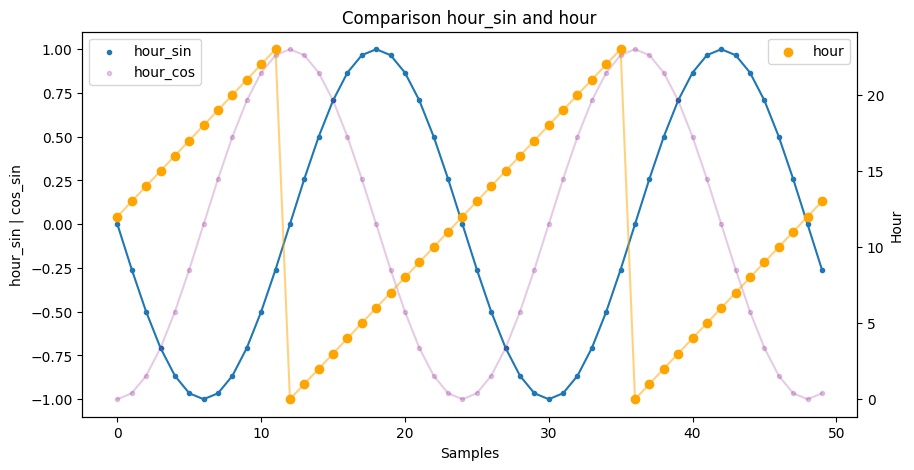

In [ ]:
# GRAPHICALLY SHOW THE ADVANTAGE OF USING SIN() FUNCTION
plt.figure(figsize=(10,5))

fig, ax1 = plt.subplots(figsize=(10,5))

# hour_sin (l)
x = df_time_mean_cluster.index[:50]
y0 = _d[_d['cluster'] == 0]['hour_sin'].iloc[:50]
y1 = _d[_d['cluster'] == 0]['hour_cos'].iloc[:50]
ax1.plot(x, y0)
ax1.plot(x, y1, alpha=0.2, color='purple')
ax1.scatter(x, y0, label='hour_sin', marker='.')
ax1.scatter(x, y1, label='hour_cos', alpha=0.2, color='purple', marker='.')
ax1.set_ylabel('hour_sin | cos_sin')
ax1.set_xlabel('Samples')
plt.legend()

# hour (r)
ax2 = ax1.twinx()
y2 = df_time_mean_cluster[df_time_mean_cluster['cluster'] == 0]['tstp'].dt.hour.iloc[:50]
ax2.plot(x, y2, color='orange', alpha=0.5)
ax2.scatter(x, y2, color='orange', label='hour')
ax2.set_ylabel('Hour')

plt.legend()
plt.title("Comparison hour_sin and hour")
plt.show()

In [ ]:
# Def. a comprehensive function, in order to be able to rapidly change cluster_ID

# CALL THE JUST CREATED FUNCTIONS to split the dataset, extract features and choose 1 cluster_ID

def extract_and_split_data(df_time_mean_cluster,
                           cluster_id,
                           train_ratio=0.7,
                           verbose=True,
                           lag_168=True,
                           sin_val=True):

  K = max(df_time_mean_cluster['cluster'])

  if cluster_id > K:
    raise ValueError(f'Cluster ID must be between 0 and {K}')

  # Call the feature engineering
  X_tot = feature_eng(df_time_mean_cluster,lag_168=lag_168, sin_val=sin_val)

  # for cluster_id in range(K):
  y_train, y_test, X_train, X_test = train_test_split(X_tot, cluster_id, train_ratio=train_ratio)

  if verbose:
    # Check
    print(f"CLUSTER_ID CONSIDERED: {cluster_id}")
    print('-'*30)
    print(f"y_train length: {len(y_train)}")
    print(f"y_test length: {len(y_test)}")

  return y_train, y_test, X_train, X_test

### Scoring functions

In [ ]:
# Define score functions
# msre, rmsre, mae, mape, rmspe
# -------------------------
def _to_numpy(y_forecast, y_test):
    """Convert inputs to flat numpy arrays."""
    y_pred = np.asarray(y_forecast, dtype=float).reshape(-1)
    y_true = np.asarray(y_test, dtype=float).reshape(-1)
    return y_pred, y_true


def _remove_zeros(y_pred, y_true):
    """Remove entries where y_true == 0 to avoid division errors."""
    mask = y_true != 0
    return y_pred[mask], y_true[mask]


# Relative Error Metrics

def msre(y_forecast, y_test):
    y_pred, y_true = _to_numpy(y_forecast, y_test)
    y_pred, y_true = _remove_zeros(y_pred, y_true)
    return np.mean(((y_pred - y_true) / y_true) ** 2)


def rmsre(y_forecast, y_test):
    return np.sqrt(msre(y_forecast, y_test))


# Absolute Error Metrics

def mae(y_forecast, y_test):
    y_pred, y_true = _to_numpy(y_forecast, y_test)
    return np.mean(np.abs(y_pred - y_true))


def mare(y_forecast, y_test):
    y_pred, y_true = _to_numpy(y_forecast, y_test)
    y_pred, y_true = _remove_zeros(y_pred, y_true)
    return np.mean(np.abs(y_pred - y_true) / np.abs(y_true))


def mape(y_forecast, y_test):
    return 100 * mare(y_forecast, y_test)


def rmspe(y_forecast, y_test):
    return 100 * rmsre(y_forecast, y_test)


def maape(y_forecast, y_test):
    y_pred, y_true = _to_numpy(y_forecast, y_test)
    y_pred, y_true = _remove_zeros(y_pred, y_true)
    return np.mean(np.arctan(np.abs((y_pred - y_true) / y_true)))


### Cluster-level forecasting algorithms (functions)

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.model_selection import TimeSeriesSplit


# Utility plotting func

def show_test_results_func(model_name, cluster_id, y_train, y_test, _train_forecasts, test_forecasts,
                      perc_window_start, perc_window_end,
                      color_y_train, color_y_test, color_y_test_forecasts):
  '''Plot the results of the forecasting '''

  # --------------------------------------------------------
  # SCORE ON TRAIN: msre, rmsre, mae, mape, rmspe
  scores_train = {
      'msre': msre(_train_forecasts, y_train),
      'rmsre': rmsre(_train_forecasts, y_train),
      'mae': mae(_train_forecasts, y_train),
      'mape': mape(_train_forecasts, y_train),
      'rmspe': rmspe(_train_forecasts, y_train),
      'maape': maape(_train_forecasts, y_train)
  }

  # SCORE ON TEST: msre, rmsre, mae, mape, rmspe
  scores_test = {
      'msre': msre(test_forecasts, y_test),
      'rmsre': rmsre(test_forecasts, y_test),
      'mae': mae(test_forecasts, y_test),
      'mape': mape(test_forecasts, y_test),
      'rmspe': rmspe(test_forecasts, y_test),
      'maape': maape(test_forecasts, y_test)
  }

  # Print the results
  print(f"SCORES ON TRAIN:\n")
  for k, v in scores_train.items():
    print(f"{k}\t{round(v,3)}")
  print('-'*30)
  print(f"SCORES ON TEST:\n")
  for k, v in scores_test.items():
    print(f"{k}\t{round(v,3)}")


  # PLOT THE RESULTS
  plt.figure(figsize=(10,5))
  plt.subplot(3,1,1)
  plt.plot(y_train.index, y_train, label='Train data', color=color_y_train)
  plt.plot(y_test.index, y_test, label='Test data', color=color_y_test)
  plt.plot(y_test.index, test_forecasts, label='Forecast on test', color=color_y_test_forecasts)
  plt.ylabel('Energy (kWh)')
  plt.legend()

  plt.subplot(3,1,2)
  plt.plot(y_test.index, y_test, label='Test data', color=color_y_test)
  plt.plot(y_test.index, test_forecasts, label='Forecast on test', color=color_y_test_forecasts)
  plt.ylabel('Energy (kWh)')
  plt.legend()
  # Analyse a shorter window of time
  plt.subplot(3,1,3)
  _idx_start = int(len(y_test)*perc_window_start)
  _idx_end = int(len(y_test)*perc_window_end)
  plt.plot(y_test.index[_idx_start:_idx_end], y_test[_idx_start:_idx_end], label='Test data', color=color_y_test)
  plt.plot(y_test.index[_idx_start:_idx_end], test_forecasts[_idx_start:_idx_end], label='Forecast on test', color=color_y_test_forecasts)
  plt.ylabel('Energy (kWh)')
  plt.legend()

  plt.xlabel('Time')
  # title subplot
  plt.suptitle(f'{model_name} - Cluster ID: {cluster_id}')
  plt.show()



def plot_learning_curve(X,y, model):
    '''Plot learning curve in terms of error (1 - score) to evaluate bias-variance'''

    # Number of folds to perform the cross-validation involved in learning_curve funcion
    n_folds = 4
    tscv = TimeSeriesSplit(n_splits=4)

    # Choose train sizes to do the learning_curve
    train_sizes = np.linspace(0.1, 1.0, 10)
    # Params
    params_learning_curve = {"X": X,
          "y": y,
          "train_sizes": train_sizes,
          "cv": tscv,
          "scoring": "neg_mean_squared_error"}

    # Run learning curve
    train_sizes, train_scores, val_scores = learning_curve(model,
                                                           **params_learning_curve)

    # Compute means and stds across folds
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)

    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    # Plot learning curve in terms of error
    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, '--', color="#F20D0D", label="Training scores")
    plt.plot(train_sizes, val_mean, color="#5B09FF", label="Cross-validation scores")

    # Confidence bands
    plt.fill_between(train_sizes,
                    train_mean - train_std,
                    train_mean + train_std,
                    color="#F20D0D", alpha=0.2)

    plt.fill_between(train_sizes,
                    val_mean - val_std,
                    val_mean + val_std,
                    color="#5B09FF", alpha=0.2)

    plt.title("Learning Curve (negative MSE)")
    plt.xlabel("Training Set Size")
    plt.ylabel("negative MSE")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.neural_network import MLPRegressor


# Decision Tree ---------------------------------------------------

def DT_func(y_train, y_test, X_train, X_test, cluster_id,
            show_test_results=True, max_depth = 10,
            perc_window_start=0.4, perc_window_end=0.6,
            plot_dt=True, plot_lc=True):
  '''Train and test the Decision Tree regressor model'''

  _max_depth = max_depth
  tree = DecisionTreeRegressor(max_depth=_max_depth, random_state=42)
  tree.fit(X_train, y_train)

  # Predict train data
  _train_forecasts = tree.predict(X_train)

  # Predict test data
  test_forecasts = tree.predict(X_test)

  # Training
  tree.fit(X_train, y_train)

  # Predictions on the train set
  _train_forecasts = tree.predict(X_train)
  # Predictions on the test set
  test_forecasts = tree.predict(X_test)

  # Show the results
  if show_test_results:
    show_test_results_func(model_name=f'Decistion Tree - max_depth: {_max_depth}', cluster_id=cluster_id,
                           y_train=y_train, y_test=y_test,
                           _train_forecasts=_train_forecasts, test_forecasts=test_forecasts,
                           perc_window_start=perc_window_start, perc_window_end=perc_window_end,
                           color_y_train='blue',
                           color_y_test='black',
                           color_y_test_forecasts='red')

  # Plot DT structure
  if plot_dt:
    plt.figure(figsize=(20,10))
    plot_tree(tree,
              feature_names=X_train.columns,
              max_depth=3,
              filled=True,
              rounded=True,
              fontsize=8)
    plt.title(f"Decision Tree (max_depth={_max_depth})")
    plt.show()

  if plot_lc:
    plot_learning_curve(X_train, y_train, tree)

  return test_forecasts



# MLP ---------------------------------------------------

def MLP_func(y_train, y_test, X_train, X_test, cluster_id,
             show_test_results=True, _hidden_layer_sizes=(32,16),
             _activation='relu', _solver='adam', _max_iter=500,
             perc_window_start=0.4, perc_window_end=0.6, plot_lc=True):
  '''Train and test the MLP NN Regressor model (Multi-Layer Perceptron)'''

  _hidden_layer_sizes = _hidden_layer_sizes
  _activation = _activation

  mlp = MLPRegressor(
      hidden_layer_sizes=_hidden_layer_sizes,
      activation=_activation,
      solver=_solver,
      max_iter=_max_iter,
      random_state=42)

  # Training
  mlp.fit(X_train, y_train)

  # Predictions on the train set
  _train_forecasts = mlp.predict(X_train)
  # Predictions on the test set
  test_forecasts = mlp.predict(X_test)

  # Show the results
  if show_test_results:
    show_test_results_func(model_name=f'MLP\nn. hidden layers: {_hidden_layer_sizes} - activation: {_activation}', cluster_id=cluster_id,
                           y_train=y_train, y_test=y_test,
                           _train_forecasts=_train_forecasts, test_forecasts=test_forecasts,
                           perc_window_start=perc_window_start, perc_window_end=perc_window_end,
                           color_y_train='blue',
                           color_y_test='black',
                           color_y_test_forecasts='red')
  if plot_lc:
    plot_learning_curve(X_train, y_train, mlp)

  return test_forecasts


In [ ]:
# CHOOSE THE CLUSTER_ID
cluster_id = 0

# CALL THE FUNCTION TO PREPARE THE DATASET, SELECT THE CLUSTER_ID AND SPLIT THE DATA
y_train, y_test, X_train, X_test = extract_and_split_data(df_time_mean_cluster,
                                                          cluster_id=cluster_id,
                                                          train_ratio=0.7,
                                                          verbose=True)

CLUSTER_ID CONSIDERED: 0
------------------------------
y_train length: 13701
y_test length: 5872


SCORES ON TRAIN:

msre	0.015
rmsre	0.124
mae	0.032
mape	7.984
rmspe	12.404
maape	0.078
------------------------------
SCORES ON TEST:

msre	0.008
rmsre	0.09
mae	0.03
mape	6.697
rmspe	8.987
maape	0.066


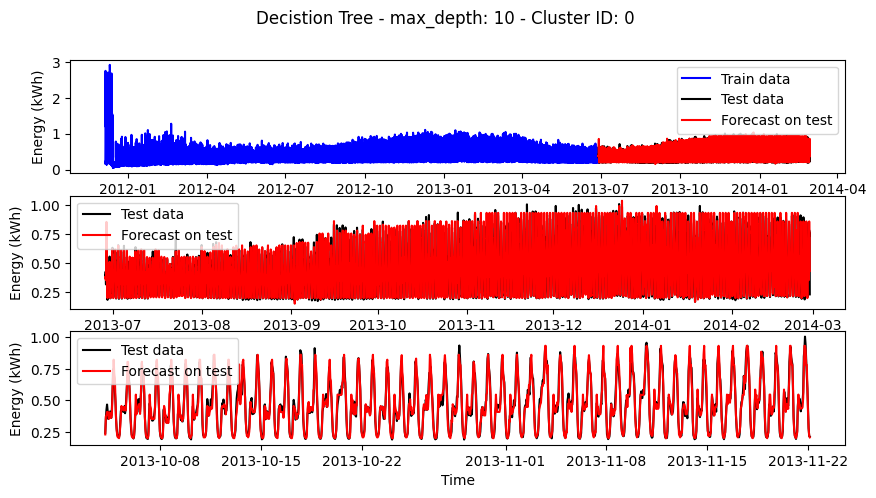

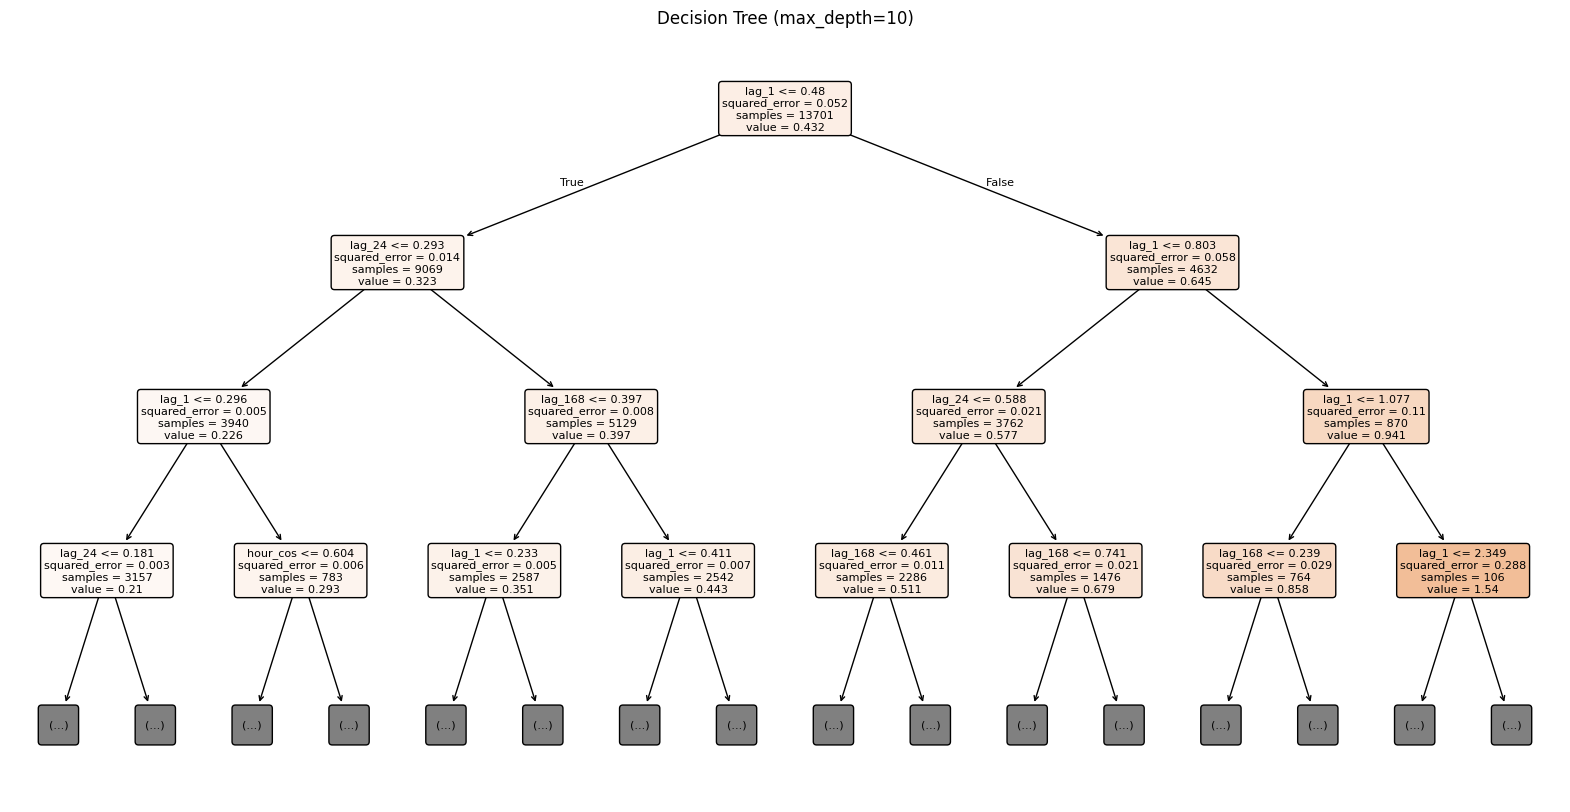

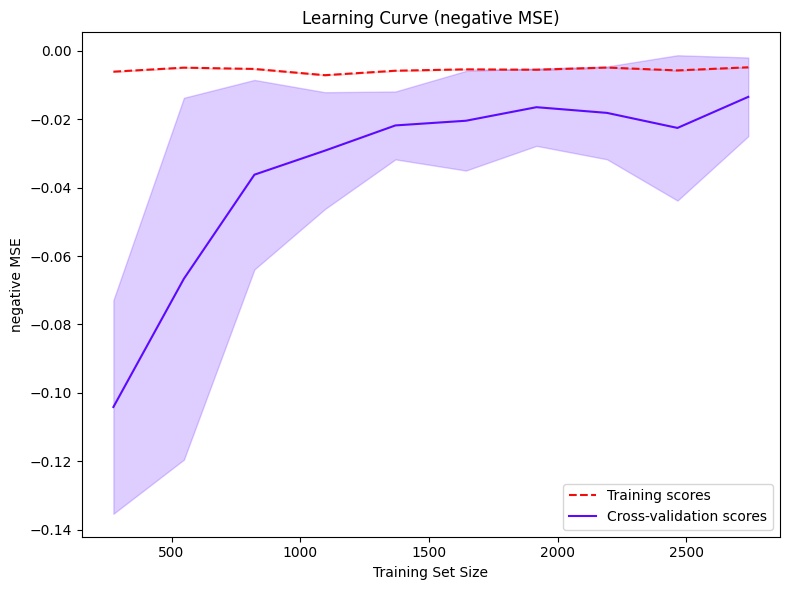

In [ ]:
# DECISION TREE METHOD
test_forecasts_DT_cluster = DT_func(y_train, y_test, X_train, X_test, cluster_id,
                            max_depth=10, show_test_results=True,
                            perc_window_start=0.4, perc_window_end=0.6)

SCORES ON TRAIN:

msre	0.076
rmsre	0.276
mae	0.05
mape	13.611
rmspe	27.623
maape	0.125
------------------------------
SCORES ON TEST:

msre	0.012
rmsre	0.111
mae	0.035
mape	8.577
rmspe	11.109
maape	0.085


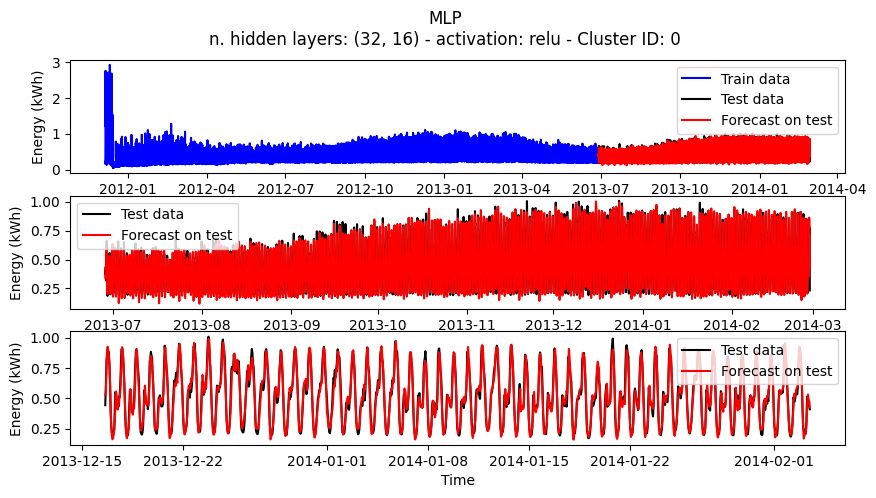

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


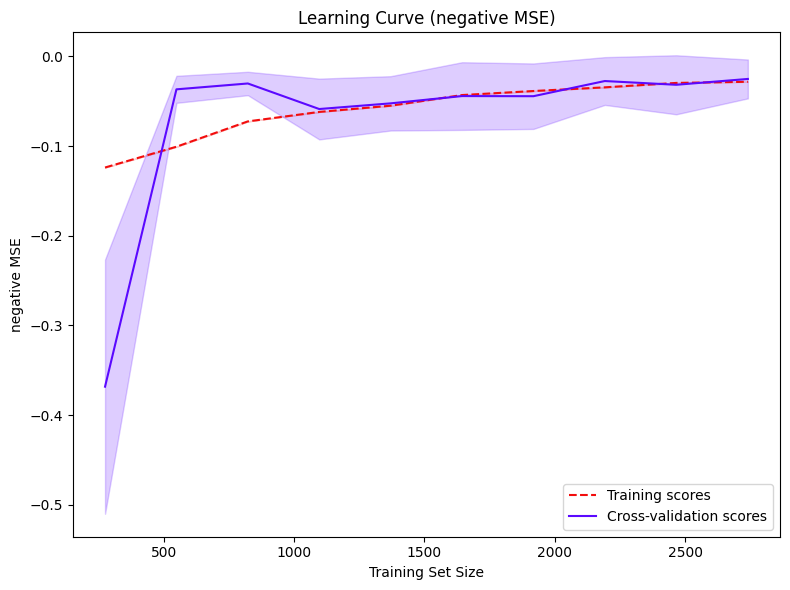

In [ ]:
# MLP METHOD
test_forecasts_mlp_cluster = MLP_func(y_train, y_test, X_train, X_test, cluster_id,
                              show_test_results=True,
                              perc_window_start=0.7, perc_window_end=0.9)


# ILF: Individual Load Forecasting (with NN)

We previously forecasted the hourly electric load in a cluster level, representing on average all the households beloging to that cluster.

GOAL: now we want to split the hourly load forecasts among each household (LCLid) in a specific cluster.

### Prepare the dataframe of individual hourly samples, scale for NN and split

In [ ]:
def prepare_df_ilf(df_time_clusterID:pd.DataFrame, df_time_mean_cluster, cluster_id):
  '''Take raw dataset, filter by cluster, add cluster hourly mean load,
  add LAGS features (1, 24), add sinusoidal values for timestamps and
  do factorization to assign an INT number to each meter'''

  # Copy the complete time series df with relatice cluster ID
  X_raw = df_time_clusterID.copy()
  # Copy the df with the average hourly load for each cluster
  _dfc = df_time_mean_cluster.copy()
  _dfc = _dfc.rename(columns={'energy(kWh)': 'energy_mean_cluster'})

  # Filter the dataframes
  X_raw = X_raw[X_raw['cluster'] == cluster_id].drop(columns=['cluster'])
  _dfc = _dfc[(_dfc['cluster'] == cluster_id)].drop(columns=['cluster'])

  # Create a new df that associates each sample with the hourly average load of its cluster
  X_ilf = X_raw.merge(_dfc, on='tstp', how='left')

  # Do feature engineering to add sinusoidal values of timestamps and LAGS
  X_ilf_ready = feature_eng(X_ilf, lag_168=False, col_name='LCLid')
  X_ilf_ready = X_ilf_ready.reset_index()

  # FACTORIZE the LCLid (smart meter ID) str values to assign a INT to each one
  int_IDs, LCLids = pd.factorize(X_ilf_ready['LCLid'])

  # Substitute the LCLids with the int_IDs
  # X_ilf_ready = X_ilf_ready.drop(columns=['LCLid'])
  X_ilf_ready['int_IDs'] = int_IDs

  # SORT DATA BY TIMESTAMP (for a correct validation-split)
  X_ilf_ready = X_ilf_ready.sort_values('tstp').reset_index(drop=True)

  return X_ilf_ready.drop(columns=['energy_mean_cluster']), int_IDs, LCLids


In [ ]:
# Use the function to prepare the dataset for the Individual Load Forecasting (ILF)
X_ilf_ready, int_IDs, LCLids = prepare_df_ilf(df_time_clusterID, df_time_mean_cluster, cluster_id)

# Check NaN values
print(f"Check NaN values (must be 0):\n{X_ilf_ready.isna().sum()}")

# Show the engineered dataset of samples of the chosen cluster
X_ilf_ready

Check NaN values (must be 0):
tstp           0
LCLid          0
energy(kWh)    0
hour_sin       0
hour_cos       0
day_sin        0
day_cos        0
month_sin      0
month_cos      0
lag_1          0
lag_24         0
int_IDs        0
dtype: int64


,tstp,LCLid,energy(kWh),hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,lag_1,lag_24,int_IDs
0,2011-11-29 12:00:00,MAC000194,0.247,1.224647e-16,-1.000000,0.781831,0.623490,-0.500000,0.866025,0.333,0.214,1
1,2011-11-29 13:00:00,MAC000194,0.233,-2.588190e-01,-0.965926,0.781831,0.623490,-0.500000,0.866025,0.247,0.183,1
2,2011-11-29 14:00:00,MAC000194,0.565,-5.000000e-01,-0.866025,0.781831,0.623490,-0.500000,0.866025,0.233,0.295,1
3,2011-11-29 15:00:00,MAC000194,0.180,-7.071068e-01,-0.707107,0.781831,0.623490,-0.500000,0.866025,0.565,0.194,1
4,2011-11-29 16:00:00,MAC000194,0.301,-8.660254e-01,-0.500000,0.781831,0.623490,-0.500000,0.866025,0.180,0.326,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1700283,2014-02-28 00:00:00,MAC004026,0.236,0.000000e+00,1.000000,-0.433884,-0.900969,0.866025,0.500000,0.620,0.223,79
1700284,2014-02-28 00:00:00,MAC003184,0.216,0.000000e+00,1.000000,-0.433884,-0.900969,0.866025,0.500000,0.900,0.267,57
1700285,2014-02-28 00:00:00,MAC003805,0.277,0.000000e+00,1.000000,-0.433884,-0.900969,0.866025,0.500000,0.495,0.557,72
1700286,2014-02-28 00:00:00,MAC001420,0.138,0.000000e+00,1.000000,-0.433884,-0.900969,0.866025,0.500000,0.459,0.215,16


In [ ]:
# Prepare a df with the previously forecasted hourly values for the chosen cluster
_dfc_test = pd.DataFrame(columns=['tstp'])
_dfc_test['tstp'] = X_test.reset_index()['tstp']
_dfc_test['forecast(kWh)'] = test_forecasts_DT_cluster
_dfc_test

,tstp,forecast(kWh)
0,2013-06-28 09:00:00,0.380952
1,2013-06-28 10:00:00,0.380952
2,2013-06-28 11:00:00,0.365752
3,2013-06-28 12:00:00,0.380952
4,2013-06-28 13:00:00,0.373718
...,...,...
5867,2014-02-27 20:00:00,0.760084
5868,2014-02-27 21:00:00,0.760084
5869,2014-02-27 22:00:00,0.714352
5870,2014-02-27 23:00:00,0.576873


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create a mask to select the test timestamps for each meter
mask = X_ilf_ready['tstp'].isin(_dfc_test['tstp'])

# Apply the mask and create the dataframe for the test and the training
tot_ilf_test  = X_ilf_ready[mask]
tot_ilf_train = X_ilf_ready[~mask]

# Set 'tstp' col as index
tot_ilf_test = tot_ilf_test.set_index('tstp')
tot_ilf_train = tot_ilf_train.set_index('tstp')

## Train/test split + isolate the smart meter ID
# Train
y_ilf_train = tot_ilf_train['energy(kWh)']
X_ilf_train = tot_ilf_train.drop(columns=['energy(kWh)','int_IDs','LCLid'])
id_input_train = tot_ilf_train['int_IDs']
LCLids_train = tot_ilf_train['LCLid']

# Test
y_ilf_test = tot_ilf_test['energy(kWh)']
X_ilf_test = tot_ilf_test.drop(columns=['energy(kWh)','int_IDs','LCLid'])
id_input_test = tot_ilf_test['int_IDs']
LCLids_test = tot_ilf_test['LCLid']



# SPLIT TRAIN → TRAIN + VALIDATION (in chronological order) -------
n_train = len(tot_ilf_train)
split_idx = int(n_train * 0.75)

# VALIDATION
y_ilf_val = y_ilf_train.iloc[split_idx:]
X_ilf_val = X_ilf_train.iloc[split_idx:]
id_input_val = id_input_train.iloc[split_idx:]

# TRAIN
y_ilf_train = y_ilf_train.iloc[:split_idx]
X_ilf_train = X_ilf_train.iloc[:split_idx]
id_input_train = id_input_train.iloc[:split_idx]


## Scale energy values for NN (since it uses a Gradient Descent, sensible to different scales)
# _cols_X = ['energy_mean_cluster','lag_1','lag_24']
# SCALE X
scaler_X = StandardScaler()
# Fit on train
X_train_scaled = scaler_X.fit_transform(X_ilf_train)
# transform on validation
X_val_scaled = scaler_X.transform(X_ilf_val)
# transform on test
X_test_scaled = scaler_X.transform(X_ilf_test)

# SCALE y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_ilf_train.values.reshape(-1,1))
y_val_scaled  = scaler_y.transform(y_ilf_val.values.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_ilf_test.values.reshape(-1,1))


In [ ]:
X_ilf_test

,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,lag_1,lag_24
tstp,,,,,,,,
2013-06-28 09:00:00,0.707107,-0.707107,-0.433884,-0.900969,1.224647e-16,-1.0,0.255,0.210
2013-06-28 09:00:00,0.707107,-0.707107,-0.433884,-0.900969,1.224647e-16,-1.0,0.388,0.472
2013-06-28 09:00:00,0.707107,-0.707107,-0.433884,-0.900969,1.224647e-16,-1.0,0.499,0.231
2013-06-28 09:00:00,0.707107,-0.707107,-0.433884,-0.900969,1.224647e-16,-1.0,0.135,0.321
2013-06-28 09:00:00,0.707107,-0.707107,-0.433884,-0.900969,1.224647e-16,-1.0,0.041,0.051
...,...,...,...,...,...,...,...,...
2014-02-28 00:00:00,0.000000,1.000000,-0.433884,-0.900969,8.660254e-01,0.5,0.620,0.223
2014-02-28 00:00:00,0.000000,1.000000,-0.433884,-0.900969,8.660254e-01,0.5,0.900,0.267
2014-02-28 00:00:00,0.000000,1.000000,-0.433884,-0.900969,8.660254e-01,0.5,0.495,0.557


### Build the Keras NN model

Epoch 1/100
12379/12379 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 0.5204 - val_loss: 0.5843
Epoch 2/100
12379/12379 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.4993 - val_loss: 0.5349
Epoch 3/100
12379/12379 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.4967 - val_loss: 0.5106
Epoch 4/100
12379/12379 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.4956 - val_loss: 0.5060
Epoch 5/100
12379/12379 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.4953 - val_loss: 0.5041
Epoch 6/100
12379/12379 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.4951 - val_loss: 0.5043
Epoch 7/100
12379/12379 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.4948 - val_loss: 0.5017
Epoch 8/100
12379/12379 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - loss: 0.4946 - val_loss: 0.5006
Epoch 9/100
12379/12379 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 0.4945 - val_loss: 0.5002
Epoch 10/100
12379/12379 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.4945 - val_loss: 0.4998
Epoch 11/100
12379/12379 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - loss: 0.4946 - val

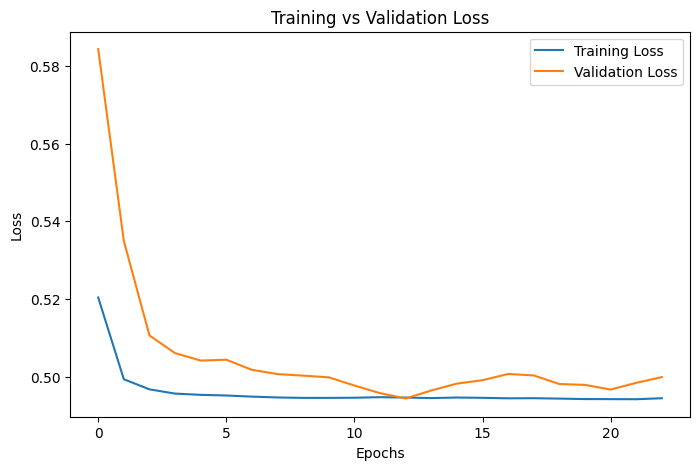

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dense, Concatenate, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam



def build_model_keras(num_ids, n_input_features, id_embedding_dim=8, h1=5, n_output_features=1):

    # Input ID
    id_input = Input(shape=(1,), name="id_input")  # ID smart meter
    id_emb = Embedding(input_dim=num_ids, output_dim=id_embedding_dim, name="id_embedding")(id_input)
    id_emb = Flatten()(id_emb)

    # Temporal input
    temp_input = Input(shape=(n_input_features,), name="temp_features")

    # Concatenate embedding + temporal features
    x = Concatenate()([temp_input, id_emb])

    # Hidden layer
    x = Dense(h1, activation='sigmoid')(x)

    # Output
    output = Dense(n_output_features, activation='linear')(x)

    model = Model(inputs=[temp_input, id_input], outputs=output)

    optimizer = Adam(learning_rate=0.01)
    model.compile(optimizer=optimizer, loss='mse')

    return model


# TRAINING
# ---------
model = build_model_keras(
    num_ids = len(X_ilf_ready['int_IDs'].unique()),
    n_input_features = X_ilf_train.shape[1],
    id_embedding_dim = 8,
    h1 = 5,
    n_output_features = 1
    )

# Add early stopping callback to stop the training if the validation loss gets worse
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Fit the model
history = model.fit(
    x=[X_train_scaled, id_input_train],
    y=y_train_scaled,
    validation_data=([X_val_scaled, id_input_val],y_val_scaled),
    epochs=100,
    batch_size=64,
    shuffle=False, # important for time series data
    verbose=1,
    callbacks=[early_stop]
)

# Plot the mse loss during the iterations (EPOCHS) in the training
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8,5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


### Individual forecasting; predict and show the results

In [ ]:
# Predictions on training set
_ilf_train_forecasts = model.predict([X_train_scaled, id_input_train])

# Predictions on test set
test_predictions = model.predict([X_test_scaled, id_input_test])



24758/24758 ━━━━━━━━━━━━━━━━━━━━ 37s 1ms/step
20125/20125 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step


In [ ]:
# De-scale the test data and the results to print
y_pred = scaler_y.inverse_transform(test_predictions.reshape(-1,1))
y_train_pred = scaler_y.inverse_transform(_ilf_train_forecasts.reshape(-1,1))


In [ ]:
def calc_performance_ILF(y_train_pred, y_ilf_train, test_forecasts, y_ilf_test):
  ''' the results of the forecasting '''

  y_train_pred = np.asarray(y_train_pred).reshape(-1)
  y_ilf_train = np.asarray(y_ilf_train).reshape(-1)
  test_forecasts = np.asarray(test_forecasts).reshape(-1)
  y_ilf_test = np.asarray(y_ilf_test).reshape(-1)

  # --------------------------------------------------------
  # SCORE ON TRAIN: msre, rmsre, mae, mape, rmspe
  scores_train = {
      'msre': msre(y_train_pred, y_ilf_train),
      'rmsre': rmsre(y_train_pred, y_ilf_train),
      'mae': mae(y_train_pred, y_ilf_train),
      'mape': mape(y_train_pred, y_ilf_train),
      'rmspe': rmspe(y_train_pred, y_ilf_train),
      'maape': maape(y_train_pred, y_ilf_train)
  }

  # SCORE ON TEST: msre, rmsre, mae, mape, rmspe
  scores_test = {
      'msre': msre(test_forecasts, y_ilf_test),
      'rmsre': rmsre(test_forecasts, y_ilf_test),
      'mae': mae(test_forecasts, y_ilf_test),
      'mape': mape(test_forecasts, y_ilf_test),
      'rmspe': rmspe(test_forecasts, y_ilf_test),
      'maape': maape(test_forecasts, y_ilf_test)
  }

  # Print the results
  print(f"SCORES ON TRAIN:\n")
  for k, v in scores_train.items():
    print(f"{k}\t{round(v,3)}")
  print('-'*30)
  print(f"SCORES ON TEST:\n")
  for k, v in scores_test.items():
    print(f"{k}\t{round(v,3)}")

print(f'Results on the ILF performance on all the smart meters of cluster {cluster_id}')
calc_performance_ILF(y_train_pred, y_ilf_train, y_pred, y_ilf_test)

Results on the ILF performance on all the smart meters of cluster 0
SCORES ON TRAIN:

msre	9.062
rmsre	3.01
mae	0.196
mape	65.202
rmspe	301.032
maape	0.412
------------------------------
SCORES ON TEST:

msre	11.662
rmsre	3.415
mae	0.192
mape	65.287
rmspe	341.49
maape	0.414


Results on the ILF performance on smart meter MAC005134 of cluster 0:
-------------------------------------------------- 

SCORES ON TRAIN:

msre	0.338
rmsre	0.582
mae	0.143
mape	40.603
rmspe	58.162
maape	0.341
------------------------------
SCORES ON TEST:

msre	0.259
rmsre	0.509
mae	0.135
mape	37.242
rmspe	50.85
maape	0.325
Results on the ILF performance on smart meter MAC005134 of cluster 0:
-------------------------------------------------- 

SCORES ON TRAIN:

msre	0.338
rmsre	0.582
mae	0.143
mape	40.603
rmspe	58.162
maape	0.341
------------------------------
SCORES ON TEST:

msre	0.259
rmsre	0.509
mae	0.135
mape	37.242
rmspe	50.85
maape	0.325


/tmp/ipykernel_788/1670218490.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  calc_performance_ILF(y_train_pred[__idx_train], y_ilf_train[__idx_train], y_pred[__idx_test], y_ilf_test[__idx_test])
/tmp/ipykernel_788/1670218490.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_ilf_train[__idx_train],
/tmp/ipykernel_788/1670218490.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_ilf_test[__idx_test]
/tmp/ipykernel_788/1

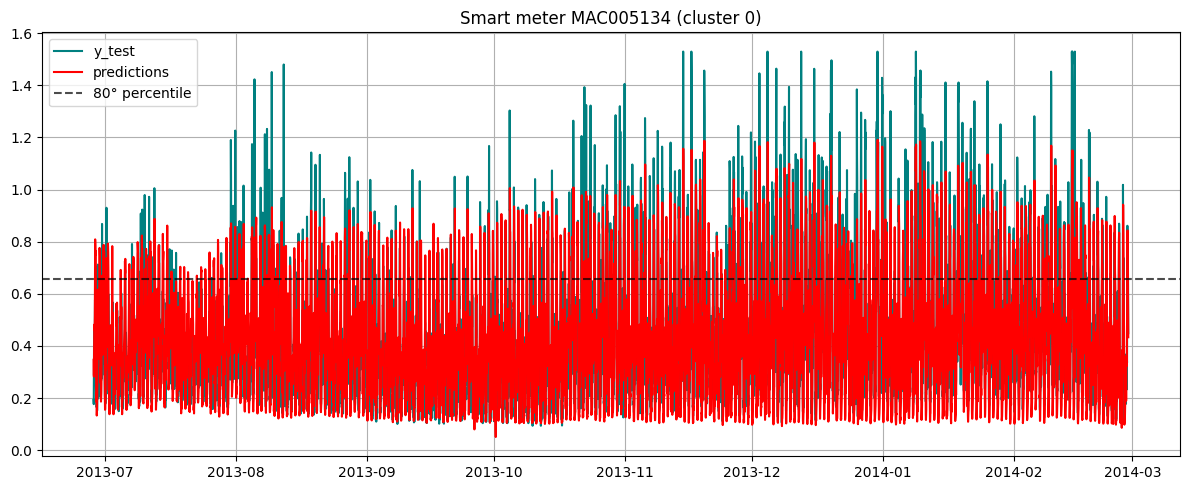

In [ ]:
# Select the number of a smart meter ID
selected_ID = 100 # <--- select ID of the smart meter to show

# Find which LCLid actually corresponds to select_ID
id_to_lclid = {i: lcl for i, lcl in enumerate(LCLids)}
matching_LCLid = id_to_lclid[selected_ID]

# Get the idx to filter the selected smart meter samples
__idx_train = id_input_train.reset_index().index[id_input_train == selected_ID]
__idx_test = id_input_test.reset_index().index[id_input_test == selected_ID]

# Calculate the performance metrics for the selected smart meter
print(f'Results on the ILF performance on smart meter {matching_LCLid} of cluster {cluster_id}:')
print('-'*50,'\n')
calc_performance_ILF(y_train_pred[__idx_train], y_ilf_train[__idx_train], y_pred[__idx_test], y_ilf_test[__idx_test])


# 95° PERCENTILE
q80 = y_ilf_test.quantile(0.80)
# Percentile mask
mask_80 = (y_ilf_test >= q80)
# Performance metrics
print(f'Results on the ILF performance on smart meter {matching_LCLid} of cluster {cluster_id}:')
print('-'*50, '\n')

calc_performance_ILF(
    y_train_pred[__idx_train],
    y_ilf_train[__idx_train],
    y_pred[__idx_test],
    y_ilf_test[__idx_test]
)

# PLOT
plt.figure(figsize=(12,5))

# True test values
plt.plot(
    y_ilf_test[__idx_test].index,
    y_ilf_test[__idx_test],
    label='y_test', color='teal'
)

# Preds
plt.plot(
    y_ilf_test[__idx_test].index,
    y_pred[__idx_test],
    label='predictions', color='red'
)

# Percentile line
plt.axhline(
    q80,
    color='black',
    linestyle='--',
    alpha=0.7,
    label='80° percentile',
)

plt.title(f"Smart meter {matching_LCLid} (cluster {cluster_id})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

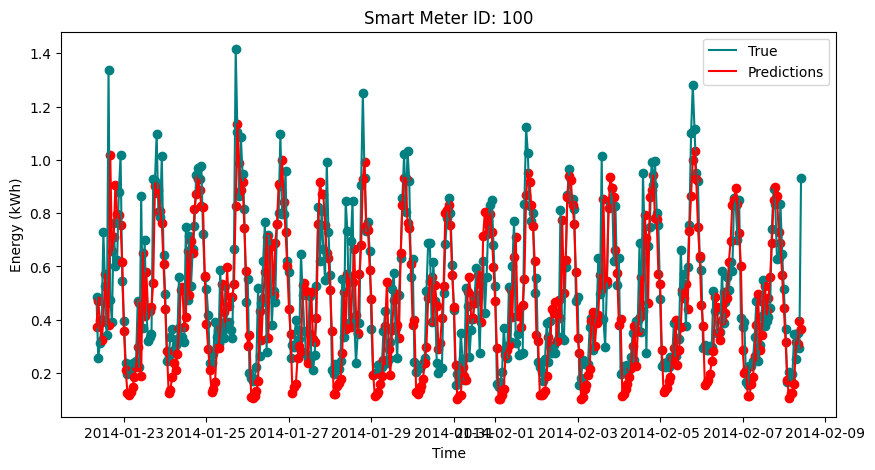

In [ ]:
series_test = y_ilf_test.iloc[__idx_test]
pred_test = y_pred[__idx_test]

start_perc, end_perc = 0.85, 0.92 # <-- choose the time window %

start, end = int(start_perc*len(series_test)), int(end_perc*len(pred_test))

# PLOT THE ILF WITHIN A SMALLER TIME WINDOW
time = series_test.index[start:end]
y_true = series_test.iloc[start:end]
_y_pred = pred_test[start:end]

plt.figure(figsize=(10,5))
plt.plot(time, y_true, label='True', color='teal')
plt.scatter(time, y_true, color='teal')
plt.plot(time, _y_pred, label='Predictions', color='red')
plt.scatter(time, _y_pred, color='red')


plt.xlabel('Time')
plt.ylabel('Energy (kWh)')
plt.title(f'Smart Meter ID: {selected_ID}')
plt.legend()
plt.show()

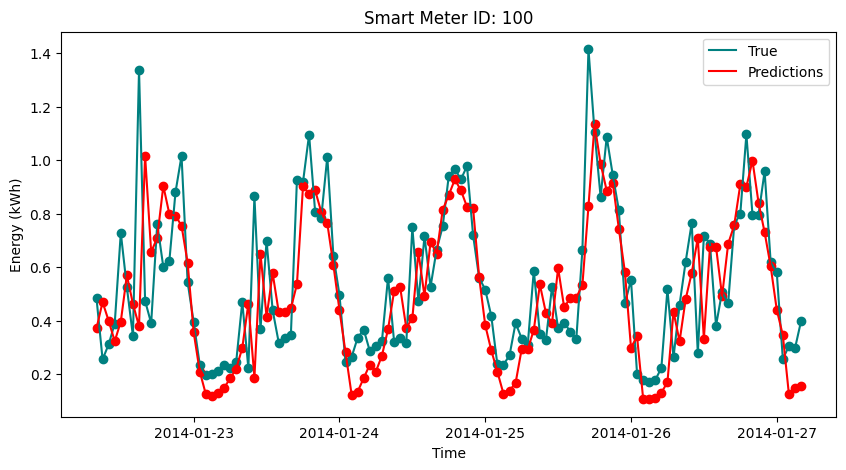

In [ ]:
series_test = y_ilf_test.iloc[__idx_test]
pred_test = y_pred[__idx_test]

start_perc, end_perc = 0.85, 0.87 # <-- choose the time window %

start, end = int(start_perc*len(series_test)), int(end_perc*len(pred_test))

# PLOT THE ILF WITHIN A SMALLER TIME WINDOW
time = series_test.index[start:end]
y_true = series_test.iloc[start:end]
_y_pred = pred_test[start:end]

plt.figure(figsize=(10,5))
plt.plot(time, y_true, label='True', color='teal')
plt.scatter(time, y_true, color='teal')
plt.plot(time, _y_pred, label='Predictions', color='red')
plt.scatter(time, _y_pred, color='red')


plt.xlabel('Time')
plt.ylabel('Energy (kWh)')
plt.title(f'Smart Meter ID: {selected_ID}')
plt.legend()
plt.show()

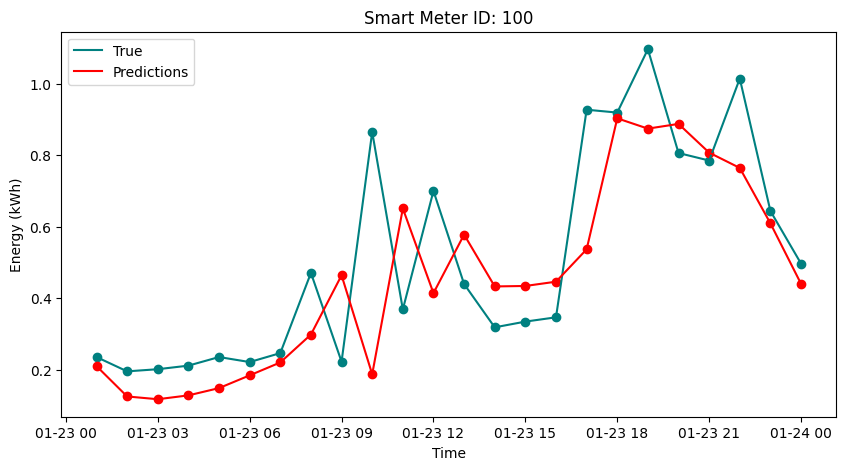

In [ ]:
series_test = y_ilf_test.iloc[__idx_test]
pred_test = y_pred[__idx_test]

start_perc, end_perc = 0.853, 0.857 # <-- choose the time window %

start, end = int(start_perc*len(series_test)), int(end_perc*len(pred_test))

# PLOT THE ILF WITHIN A SMALLER TIME WINDOW
time = series_test.index[start:end]
y_true = series_test.iloc[start:end]
_y_pred = pred_test[start:end]

plt.figure(figsize=(10,5))
plt.plot(time, y_true, label='True', color='teal')
plt.scatter(time, y_true, color='teal')
plt.plot(time, _y_pred, label='Predictions', color='red')
plt.scatter(time, _y_pred, color='red')


plt.xlabel('Time')
plt.ylabel('Energy (kWh)')
plt.title(f'Smart Meter ID: {selected_ID}')
plt.legend()
plt.show()

In [ ]:
# SAVE USELEFUL .csv

#X_ilf_test['LCLid'] = LCLids_test.values
#X_ilf_test.to_csv(drive_folder_path + 'data/X_ilf_test.csv')

#X_ilf_train['LCLid'] = LCLids_train.values
#X_ilf_train.to_csv(drive_folder_path + 'data/X_ilf_train.csv')

#_y_ilf_test = y_ilf_test.reset_index()
#_y_ilf_test['LCLid'] = LCLids_test.reset_index()[['LCLid']]
#_y_ilf_test.to_csv(drive_folder_path + 'data/y_ilf_test.csv')

#_y_ilf_train = y_ilf_train.reset_index()
#_y_ilf_train['LCLid'] = LCLids_train.reset_index()[['LCLid']]
#_y_ilf_train.to_csv(drive_folder_path + 'data/y_ilf_train.csv')


In [ ]:
'''
# Convert into DataFrame
df_pred = pd.DataFrame(test_predictions, columns=['prediction'])
# df_pred['LCLid'] = LCLids_train.values
# Save CSV
df_pred.to_csv(drive_folder_path + 'data/test_predictions.csv', index=False)


df_pred_meter = pd.DataFrame(test_predictions[__idx_test], columns=['prediction'])
df_pred_meter['LCLid'] = LCLids_test[__idx_test].values
df_pred_meter.to_csv(drive_folder_path + f'data/test_pred_mater_{matching_LCLid}.csv', index=False)
'''

"\n# Convert into DataFrame\ndf_pred = pd.DataFrame(test_predictions, columns=['prediction'])\n#\xa0df_pred['LCLid'] = LCLids_train.values\n# Save CSV\ndf_pred.to_csv(drive_folder_path + 'data/test_predictions.csv', index=False)\n\n\ndf_pred_meter = pd.DataFrame(test_predictions[__idx_test], columns=['prediction'])\ndf_pred_meter['LCLid'] = LCLids_test[__idx_test].values\ndf_pred_meter.to_csv(drive_folder_path + f'data/test_pred_mater_{matching_LCLid}.csv', index=False)\n"